# Import

In [1]:
import pandas as pd
import numpy as np
import os

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

print("Model training environment is ready!")

Model training environment is ready!


In [2]:
df = pd.read_csv("../data/processed/medical_insurance_cleaned.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1326, 7)


In [3]:
X = df.drop("expenses", axis=1)
y = df["expenses"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1326, 6)
Target shape: (1326,)


# spliting

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1060, 6)
X_test: (266, 6)
y_train: (1060,)
y_test: (266,)


# Define numerical and categorical features

In [5]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["gender", "region", "smoker"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


# Fit and transform the data

In [6]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)

Training data shape: (1060, 11)
Testing data shape: (266, 11)


# Train Linear Regression

In [7]:
linear_model = LinearRegression()

linear_model.fit(X_train_processed, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


### Make predictions

In [8]:
y_pred = linear_model.predict(X_test_processed)

print("Predictions generated successfully!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!
First 10 predictions:
[ 7718.44012825 11242.57338141  5618.40221043 10968.83974748
  4118.74098965  6531.73752765   950.20599813 10763.67162508
 -1635.57323934 34063.52962379]


### Evaluating linear regression

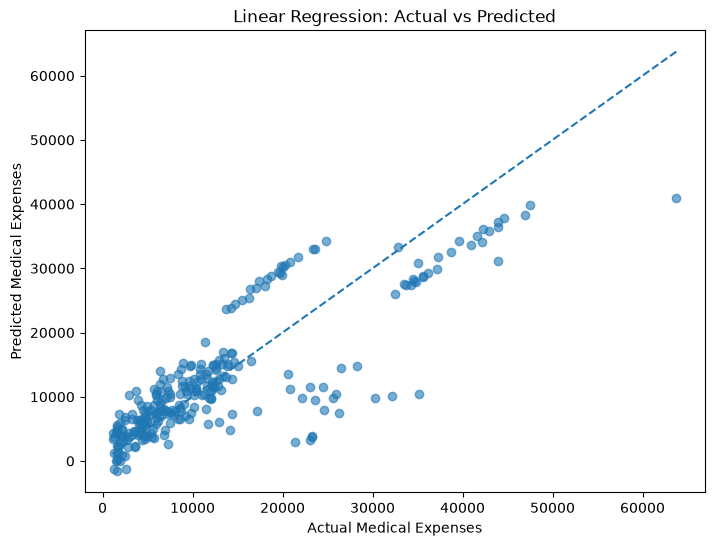

In [9]:
import matplotlib.pyplot as plt

linear_pred = linear_model.predict(X_test_processed)

plt.figure(figsize=(8, 6))

plt.scatter(y_test, linear_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Medical Expenses")
plt.ylabel("Predicted Medical Expenses")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

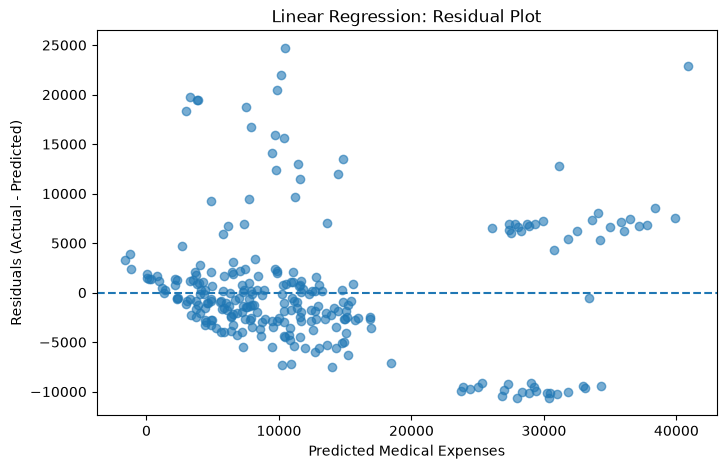

In [10]:
# Linear Regression: Residual Plot

linear_residuals = y_test - linear_pred

plt.figure(figsize=(8, 5))

plt.scatter(linear_pred, linear_residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Medical Expenses")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Linear Regression: Residual Plot")

plt.show()

In [11]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 4412.093859733528


In [12]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.6880082444726833


In [13]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 6398.138011189458


### save these baseline results

In [14]:
linear_results = {
    "Model": "Linear Regression",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}

print(linear_results)

{'Model': 'Linear Regression', 'MAE': 4412.093859733528, 'RMSE': np.float64(6398.138011189458), 'R2': 0.6880082444726833}


# Decision Tree Regression

In [15]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(X_train_processed, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


### Decision Tree predictions

In [16]:
tree_pred = tree_model.predict(X_test_processed)

print("Decision Tree predictions generated successfully!")
print(tree_pred[:10])

Decision Tree predictions generated successfully!
[ 9361.33  8534.67  1633.96 10450.55  4349.46  4137.52  2154.36  5920.1
  1625.43 39611.76]


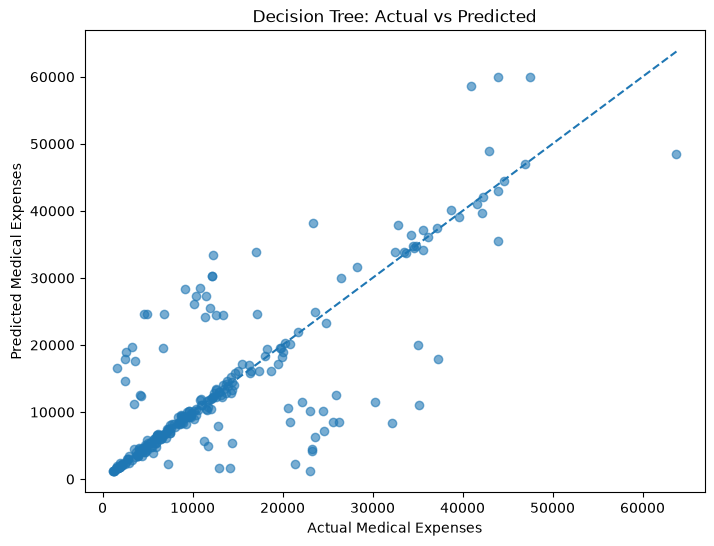

In [17]:
tree_pred = tree_model.predict(X_test_processed)

plt.figure(figsize=(8, 6))

plt.scatter(y_test, tree_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Medical Expenses")
plt.ylabel("Predicted Medical Expenses")
plt.title("Decision Tree: Actual vs Predicted")

plt.show()

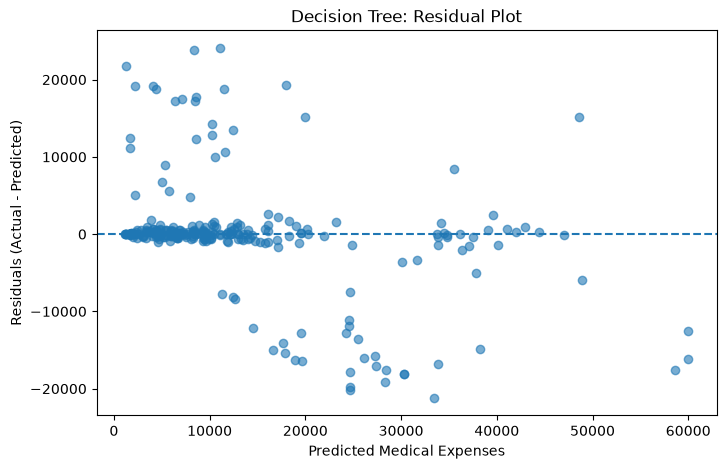

In [18]:
# Decision Tree: Residual Plot

tree_residuals = y_test - tree_pred

plt.figure(figsize=(8, 5))

plt.scatter(tree_pred, tree_residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Medical Expenses")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Decision Tree: Residual Plot")

plt.show()

In [19]:
tree_mae = mean_absolute_error(y_test, tree_pred)

print("Decision Tree MAE:", tree_mae)

Decision Tree MAE: 3667.5898872180446


In [20]:
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))

print("Decision Tree RMSE:", tree_rmse)

Decision Tree RMSE: 7270.494413429178


In [21]:
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree R² Score:", tree_r2)

Decision Tree R² Score: 0.597131046572757


In [22]:
tree_results = {
    "Model": "Decision Tree",
    "MAE": tree_mae,
    "RMSE": tree_rmse,
    "R2": tree_r2
}

print(tree_results)

{'Model': 'Decision Tree', 'MAE': 3667.5898872180446, 'RMSE': np.float64(7270.494413429178), 'R2': 0.597131046572757}


# Random Forest Regression

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [24]:
rf_pred = rf_model.predict(X_test_processed)

print("Random Forest predictions generated successfully!")
print(rf_pred[:10])

Random Forest predictions generated successfully!
[ 9008.4689  8586.7688  1681.9953 10822.5217  6982.8698  4663.5334
  2454.7533  7204.9717  2266.7893 40289.579 ]


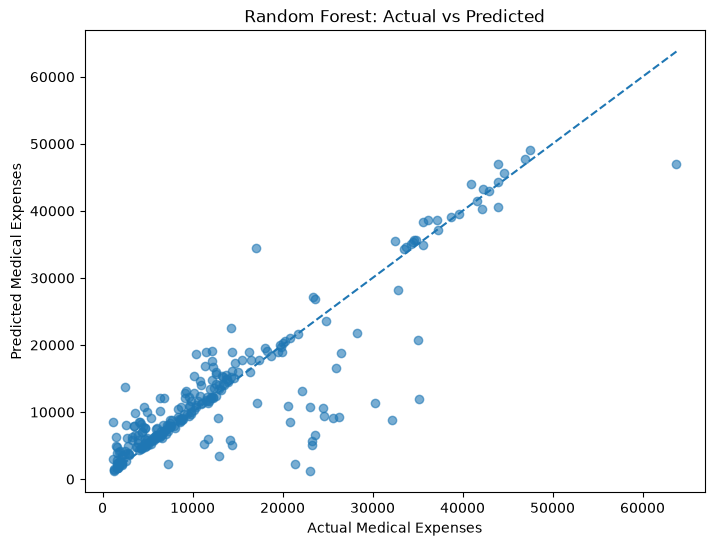

In [25]:
rf_pred = rf_model.predict(X_test_processed)

plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Medical Expenses")
plt.ylabel("Predicted Medical Expenses")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

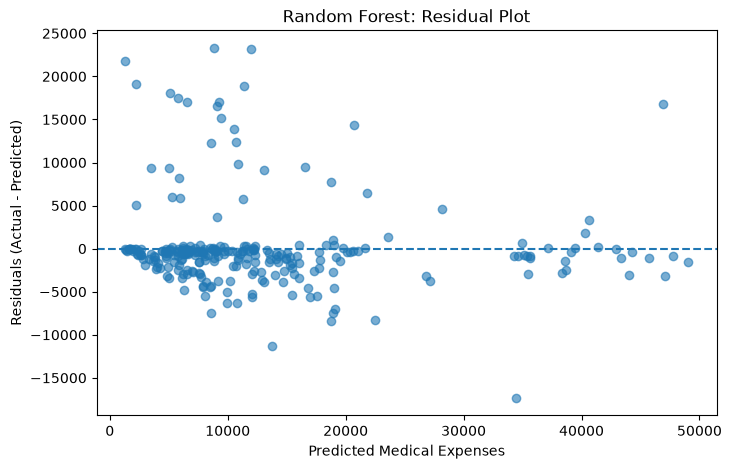

In [26]:
# Random Forest: Residual Plot

rf_residuals = y_test - rf_pred

plt.figure(figsize=(8, 5))

plt.scatter(rf_pred, rf_residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Medical Expenses")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Random Forest: Residual Plot")

plt.show()

### Evaluating random forest regression

In [27]:
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)

Random Forest MAE: 2844.805034586465


In [28]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 5276.285415601953


In [29]:
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest R² Score:", rf_r2)

Random Forest R² Score: 0.7878258501487152


In [30]:
rf_results = {
    "Model": "Random Forest",
    "MAE": rf_mae,
    "RMSE": rf_rmse,
    "R2": rf_r2
}

print(rf_results)

{'Model': 'Random Forest', 'MAE': 2844.805034586465, 'RMSE': np.float64(5276.285415601953), 'R2': 0.7878258501487152}


### Result of above 3 models

In [31]:
results = pd.DataFrame([
    linear_results,
    tree_results,
    rf_results
])

results

,Model,MAE,RMSE,R2
0,Linear Regression,4412.093860,6398.138011,0.688008
1,Decision Tree,3667.589887,7270.494413,0.597131
2,Random Forest,2844.805035,5276.285416,0.787826


# Gradient Boosting

In [32]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train_processed, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [33]:
gb_pred = gb_model.predict(X_test_processed)

print("Gradient Boosting predictions generated successfully!")
print(gb_pred[:10])

Gradient Boosting predictions generated successfully!
[ 9670.09501153  8418.65252957  3188.36589939 11424.04005639
  6563.34636408  4564.37651601  2186.38139875  7323.35124304
  1871.64815008 39900.39639657]


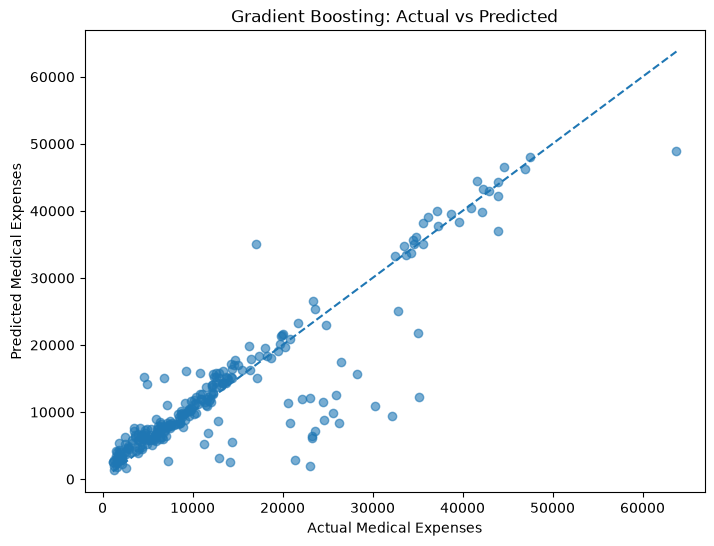

In [34]:
gb_pred = gb_model.predict(X_test_processed)

plt.figure(figsize=(8, 6))

plt.scatter(y_test, gb_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Medical Expenses")
plt.ylabel("Predicted Medical Expenses")
plt.title("Gradient Boosting: Actual vs Predicted")

plt.show()

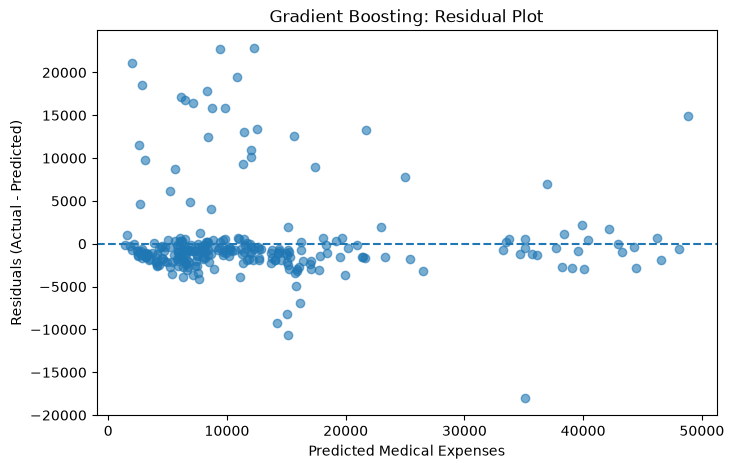

In [35]:
# Gradient Boosting: Residual Plot

gb_residuals = y_test - gb_pred

plt.figure(figsize=(8, 5))

plt.scatter(gb_pred, gb_residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Medical Expenses")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Gradient Boosting: Residual Plot")

plt.show()

In [36]:
gb_mae = mean_absolute_error(y_test, gb_pred)

print("Gradient Boosting MAE:", gb_mae)

Gradient Boosting MAE: 2795.418781622451


In [37]:
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))

print("Gradient Boosting RMSE:", gb_rmse)

Gradient Boosting RMSE: 5158.732708515373


In [38]:
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting R² Score:", gb_r2)

Gradient Boosting R² Score: 0.7971747768056415


In [39]:
gb_results = {
    "Model": "Gradient Boosting",
    "MAE": gb_mae,
    "RMSE": gb_rmse,
    "R2": gb_r2
}

print(gb_results)

{'Model': 'Gradient Boosting', 'MAE': 2795.418781622451, 'RMSE': np.float64(5158.732708515373), 'R2': 0.7971747768056415}


# All 4 models result comparision

In [40]:
results = pd.DataFrame([
    linear_results,
    tree_results,
    rf_results,
    gb_results
])

results

,Model,MAE,RMSE,R2
0,Linear Regression,4412.093860,6398.138011,0.688008
1,Decision Tree,3667.589887,7270.494413,0.597131
2,Random Forest,2844.805035,5276.285416,0.787826
3,Gradient Boosting,2795.418782,5158.732709,0.797175


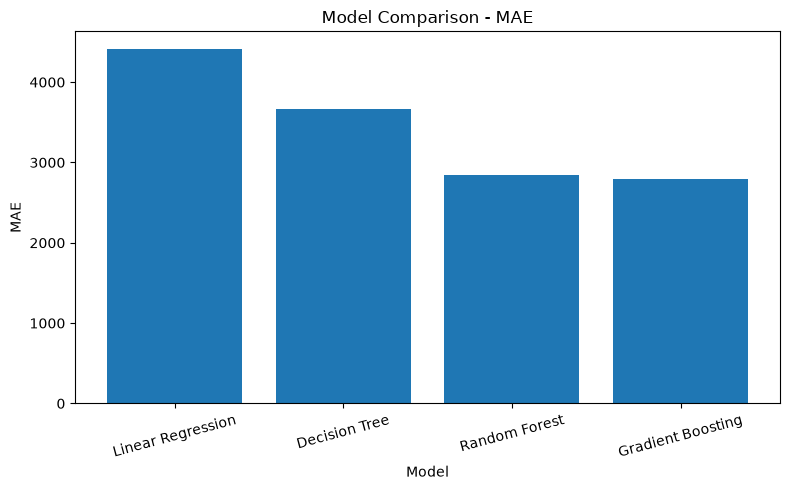

In [41]:
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["MAE"])

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Model Comparison - MAE")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

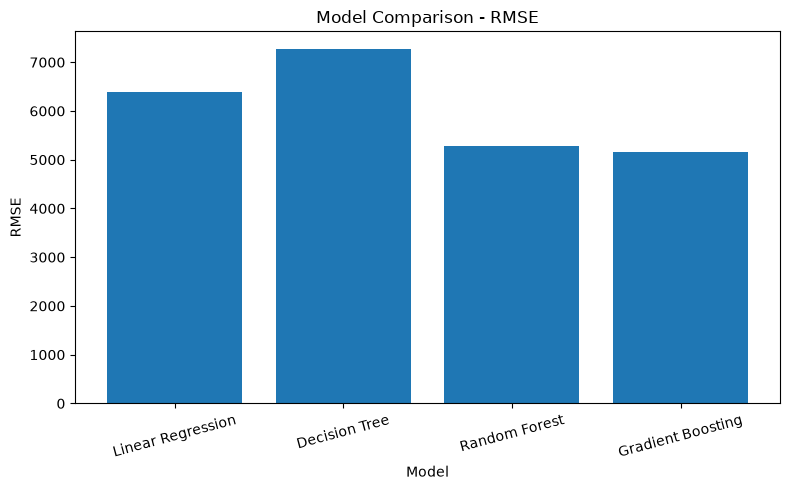

In [42]:
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["RMSE"])

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

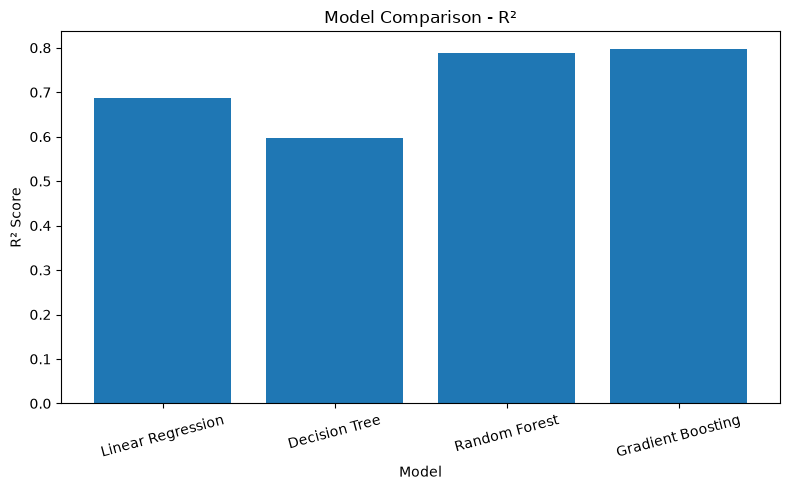

In [43]:
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["R2"])

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Comparison - R²")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# The Best Performing Model

In [44]:
best_model_mae = results.loc[results["MAE"].idxmin(), "Model"]
best_model_rmse = results.loc[results["RMSE"].idxmin(), "Model"]
best_model_r2 = results.loc[results["R2"].idxmax(), "Model"]

print("BEST MODEL BY EACH METRIC")
print("-" * 35)

print(f"Lowest MAE  : {best_model_mae}")
print(f"Lowest RMSE : {best_model_rmse}")
print(f"Highest R²  : {best_model_r2}")

BEST MODEL BY EACH METRIC
-----------------------------------
Lowest MAE  : Gradient Boosting
Lowest RMSE : Gradient Boosting
Highest R²  : Gradient Boosting


### However, we should not immediately save Gradient Boosting as the final model. The next thing we should check is whether the model is making systematically bad predictions.

In [45]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": gb_model.predict(X_test_processed)
})

comparison.head(10)

,Actual,Predicted
0,8688.86,9670.095012
1,20878.78,8418.652530
2,1634.57,3188.365899
3,10436.10,11424.040056
4,4340.44,6563.346364
5,4347.02,4564.376516
6,2150.47,2186.381399
7,6474.01,7323.351243
8,1621.34,1871.648150
9,42112.24,39900.396397


In [46]:
comparison["Error"] = comparison["Actual"] - comparison["Predicted"]

comparison.head(10)

,Actual,Predicted,Error
0,8688.86,9670.095012,-981.235012
1,20878.78,8418.652530,12460.127470
2,1634.57,3188.365899,-1553.795899
3,10436.10,11424.040056,-987.940056
4,4340.44,6563.346364,-2222.906364
5,4347.02,4564.376516,-217.356516
6,2150.47,2186.381399,-35.911399
7,6474.01,7323.351243,-849.341243
8,1621.34,1871.648150,-250.308150
9,42112.24,39900.396397,2211.843603


In [47]:
comparison["Absolute_Error"] = comparison["Error"].abs()

comparison.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Actual,Predicted,Error,Absolute_Error
34,35160.13,12306.464104,22853.665896,22853.665896
50,32108.66,9418.426158,22690.233842,22690.233842
88,23082.96,1989.963834,21092.996166,21092.996166
36,30284.64,10851.412485,19433.227515,19433.227515
14,21344.85,2806.506985,18538.343015,18538.343015
83,17085.27,35085.183740,-17999.913740,17999.913740
204,26236.58,8356.355248,17880.224752,17880.224752
238,23288.93,6137.359025,17151.570975,17151.570975
41,23241.47,6439.985611,16801.484389,16801.484389
31,23563.02,7148.957961,16414.062039,16414.062039


In [48]:
worst_indices = (
    comparison
    .sort_values("Absolute_Error", ascending=False)
    .head(10)
    .index
)

X_test.iloc[worst_indices]

,age,gender,bmi,children,region,smoker
240,55,female,26.8,1,southwest,non-smoker
925,44,male,29.7,2,northeast,non-smoker
425,19,male,33.1,0,southwest,non-smoker
382,50,male,25.4,2,northwest,non-smoker
101,18,female,30.1,0,northeast,non-smoker
259,20,female,30.4,1,southeast,smoker
678,47,female,24.1,1,southwest,non-smoker
462,28,female,24.3,1,northeast,non-smoker
997,25,male,25.0,2,northeast,non-smoker
1200,39,male,34.1,2,southeast,non-smoker


In [49]:
worst_cases = X_test.iloc[worst_indices].copy()

worst_cases["Actual"] = y_test.iloc[worst_indices].values
worst_cases["Predicted"] = comparison.iloc[worst_indices]["Predicted"].values
worst_cases["Error"] = comparison.iloc[worst_indices]["Error"].values
worst_cases["Absolute_Error"] = comparison.iloc[worst_indices]["Absolute_Error"].values

worst_cases

,age,gender,bmi,children,region,smoker,Actual,Predicted,Error,Absolute_Error
240,55,female,26.8,1,southwest,non-smoker,35160.13,12306.464104,22853.665896,22853.665896
925,44,male,29.7,2,northeast,non-smoker,32108.66,9418.426158,22690.233842,22690.233842
425,19,male,33.1,0,southwest,non-smoker,23082.96,1989.963834,21092.996166,21092.996166
382,50,male,25.4,2,northwest,non-smoker,30284.64,10851.412485,19433.227515,19433.227515
101,18,female,30.1,0,northeast,non-smoker,21344.85,2806.506985,18538.343015,18538.343015
259,20,female,30.4,1,southeast,smoker,17085.27,35085.183740,-17999.913740,17999.913740
678,47,female,24.1,1,southwest,non-smoker,26236.58,8356.355248,17880.224752,17880.224752
462,28,female,24.3,1,northeast,non-smoker,23288.93,6137.359025,17151.570975,17151.570975
997,25,male,25.0,2,northeast,non-smoker,23241.47,6439.985611,16801.484389,16801.484389
1200,39,male,34.1,2,southeast,non-smoker,23563.02,7148.957961,16414.062039,16414.062039


In [50]:
from sklearn.model_selection import GridSearchCV

print("Grid Search is ready!")

Grid Search is ready!


In [51]:
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

print("Parameter grid created successfully!")

Parameter grid created successfully!


In [52]:
gb_base = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

print("Grid Search model configured successfully!")

Grid Search model configured successfully!


In [53]:
grid_search.fit(X_train_processed, y_train)

print("Grid Search completed successfully!")

Grid Search completed successfully!


In [54]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV RMSE:")
print(np.sqrt(-grid_search.best_score_))

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best CV RMSE:
4587.368778519315


In [55]:
best_gb_model = grid_search.best_estimator_

print("Best Gradient Boosting model retrieved successfully!")

Best Gradient Boosting model retrieved successfully!


In [56]:
best_gb_pred = best_gb_model.predict(X_test_processed)

print("Predictions generated successfully!")

Predictions generated successfully!


In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tuned_mae = mean_absolute_error(y_test, best_gb_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, best_gb_pred))
tuned_r2 = r2_score(y_test, best_gb_pred)

print("TUNED GRADIENT BOOSTING RESULTS")
print("-" * 40)
print(f"MAE  : {tuned_mae:.2f}")
print(f"RMSE : {tuned_rmse:.2f}")
print(f"R²   : {tuned_r2:.4f}")


TUNED GRADIENT BOOSTING RESULTS
----------------------------------------
MAE  : 2785.11
RMSE : 5134.99
R²   : 0.7990


In [58]:
tuned_gb_results = {
    "Model": "Tuned Gradient Boosting",
    "MAE": tuned_mae,
    "RMSE": tuned_rmse,
    "R2": tuned_r2
}

final_results = pd.DataFrame([
    linear_results,
    tree_results,
    rf_results,
    gb_results,
    tuned_gb_results
])

final_results

,Model,MAE,RMSE,R2
0,Linear Regression,4412.093860,6398.138011,0.688008
1,Decision Tree,3667.589887,7270.494413,0.597131
2,Random Forest,2844.805035,5276.285416,0.787826
3,Gradient Boosting,2795.418782,5158.732709,0.797175
4,Tuned Gradient Boosting,2785.111756,5134.985414,0.799038


In [59]:
best_model = final_results.loc[
    final_results["R2"].idxmax()
]

print("BEST MODEL")
print("-" * 30)
print("Model:", best_model["Model"])
print(f"MAE  : {best_model['MAE']:.2f}")
print(f"RMSE : {best_model['RMSE']:.2f}")
print(f"R²   : {best_model['R2']:.4f}")

BEST MODEL
------------------------------
Model: Tuned Gradient Boosting
MAE  : 2785.11
RMSE : 5134.99
R²   : 0.7990


In [60]:
import joblib

joblib.dump(best_gb_model, "../models/gradient_boosting_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [61]:
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("Preprocessor saved successfully!")


Preprocessor saved successfully!


In [62]:
print("Saved model files:")
print(os.listdir("../models"))

Saved model files:
['gradient_boosting_model.pkl', 'preprocessor.pkl']


What percentage of the model's predictions are within 10% of the actual medical expense?

For example, if the actual expense is ₹10,000, predictions between ₹9,000 and ₹11,000 count as being within ±10%.

In [63]:
# Prediction accuracy within ±10%

def within_10_percent_accuracy(y_actual, y_pred):
    percentage_error = abs(y_actual - y_pred) / y_actual
    return (percentage_error <= 0.10).mean() * 100


accuracy_results = {
    "Linear Regression": within_10_percent_accuracy(y_test, linear_pred),
    "Decision Tree": within_10_percent_accuracy(y_test, tree_pred),
    "Random Forest": within_10_percent_accuracy(y_test, rf_pred),
    "Gradient Boosting": within_10_percent_accuracy(y_test, gb_pred),
    "Tuned Gradient Boosting": within_10_percent_accuracy(y_test, best_gb_pred)
}

for model, accuracy in accuracy_results.items():
    print(f"{model}: {accuracy:.2f}%")

Linear Regression: 15.41%
Decision Tree: 65.04%
Random Forest: 46.99%
Gradient Boosting: 40.23%
Tuned Gradient Boosting: 32.71%


In [64]:
final_results["Within ±10% (%)"] = final_results["Model"].map(accuracy_results)

final_results

,Model,MAE,RMSE,R2,Within ±10% (%)
0,Linear Regression,4412.093860,6398.138011,0.688008,15.413534
1,Decision Tree,3667.589887,7270.494413,0.597131,65.037594
2,Random Forest,2844.805035,5276.285416,0.787826,46.992481
3,Gradient Boosting,2795.418782,5158.732709,0.797175,40.225564
4,Tuned Gradient Boosting,2785.111756,5134.985414,0.799038,32.706767


### Saving for further use

In [66]:
joblib.dump(linear_model, "../models/linear_regression_model.pkl")
joblib.dump(tree_model, "../models/decision_tree_model.pkl")
joblib.dump(rf_model, "../models/random_forest_model.pkl")
joblib.dump(gb_model, "../models/gradient_boosting_baseline_model.pkl")
joblib.dump(best_gb_model, "../models/gradient_boosting_model.pkl")
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("All models and preprocessor saved successfully!")

All models and preprocessor saved successfully!
